In [1]:
import sys
print(sys.executable)

/home/vasanth/projects/cardiac_vr_project/cardiac_vr_env/bin/python


In [2]:
import torch

print("PyTorch Version:", torch.__version__)

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())

PyTorch Version: 2.12.0+cu130
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3050 4GB Laptop GPU
GPU Count: 1


In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TorchVision:", torchvision.__version__)

print("\nCore imports successful")

OpenCV: 4.13.0
NumPy: 2.4.6
Pandas: 2.3.3
TorchVision: 0.27.0+cu130

Core imports successful


In [7]:
from pathlib import Path

PROJECT_ROOT = Path("../../")

DATA_DIR = PROJECT_ROOT / "data"
ECHONET_DIR = DATA_DIR / "EchoNet-Dynamic"

print("Project Root:", PROJECT_ROOT.resolve())

print("Data Exists:", DATA_DIR.exists())
print("EchoNet Exists:", ECHONET_DIR.exists())

Project Root: /home/vasanth/projects/cardiac_vr_project
Data Exists: True
EchoNet Exists: True


In [8]:
filelist_path = ECHONET_DIR / "FileList.csv"

print(filelist_path)
print("CSV Exists:", filelist_path.exists())

../../data/EchoNet-Dynamic/FileList.csv
CSV Exists: True


In [9]:
filelist = pd.read_csv(filelist_path)

print("Dataset Shape:", filelist.shape)

filelist.head()

Dataset Shape: (10030, 9)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [10]:
VIDEOS_DIR = ECHONET_DIR / "Videos"

print("Videos Folder Exists:", VIDEOS_DIR.exists())

video_files = list(VIDEOS_DIR.glob("*.avi"))

print("Total Videos:", len(video_files))

video_files[:5]

Videos Folder Exists: True
Total Videos: 10030


[PosixPath('../../data/EchoNet-Dynamic/Videos/0X1EA7A5960D8A5576.avi'),
 PosixPath('../../data/EchoNet-Dynamic/Videos/0X56A3F4651716DAFF.avi'),
 PosixPath('../../data/EchoNet-Dynamic/Videos/0X51B5B37B6F4A8CA8.avi'),
 PosixPath('../../data/EchoNet-Dynamic/Videos/0X7E379B92108E37EF.avi'),
 PosixPath('../../data/EchoNet-Dynamic/Videos/0X40F87CEA33AD96E4.avi')]

In [11]:
sample_video = video_files[0]

print(sample_video)

cap = cv2.VideoCapture(str(sample_video))

print("Opened Successfully:", cap.isOpened())

../../data/EchoNet-Dynamic/Videos/0X1EA7A5960D8A5576.avi
Opened Successfully: True


In [12]:
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fps = cap.get(cv2.CAP_PROP_FPS)

print("Total Frames:", total_frames)

print("Width:", frame_width)

print("Height:", frame_height)

print("FPS:", fps)

Total Frames: 72
Width: 112
Height: 112
FPS: 50.0


In [13]:
frame_idx = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

ret, frame = cap.read()

print("Read Successful:", ret)

print("Frame Shape:", frame.shape)

Read Successful: True
Frame Shape: (112, 112, 3)


In [14]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

print(frame_rgb.shape)

(112, 112, 3)


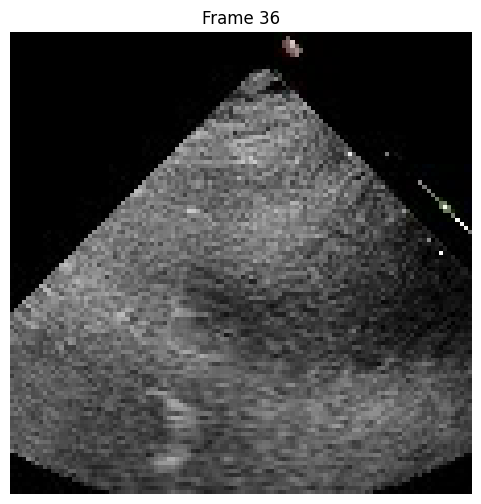

In [15]:
plt.figure(figsize=(6,6))

plt.imshow(frame_rgb)

plt.title(f"Frame {frame_idx}")

plt.axis("off")

plt.show()

In [16]:
cap.release()

print("Video resource released")

Video resource released


In [17]:
from torchvision import models

model = models.efficientnet_b3(weights="DEFAULT")

model.eval()

print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /home/vasanth/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:02<00:00, 19.6MB/s]

EfficientNet


In [18]:
dummy = torch.randn(1, 3, 224, 224)

print(dummy.shape)

torch.Size([1, 3, 224, 224])


In [19]:
with torch.no_grad():
    out = model(dummy)

print(out.shape)

torch.Size([1, 1000])


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

model = model.to(device)

dummy = dummy.to(device)

with torch.no_grad():
    out = model(dummy)

print("Output Shape:", out.shape)

print("Output Device:", out.device)

Using Device: cuda
Output Shape: torch.Size([1, 1000])
Output Device: cuda:0


In [21]:
print("00_system_check.ipynb completed successfully")

00_system_check.ipynb completed successfully
